# Estudo de Ablação - Simulador de distorção de preferências


Neste documento, detalho as ablações executadas no simulador de preferências. Previamente, notamos que os resultados do simulador para o movielens-1m apresentavam alta oscilação em termos de MACE e divergência KL média. Desde então, realizei o seguinte:


1. Revisão completa do código: verificação de possíveis _bugs_ na implementação de métricas ou no cálculo da distribuição de gêneros na recomendação e histórico do usuário. Encontrei pequenos bugs no cálculo da distribuição de gêneros que introduziam um leve ruído no cálculo a divergência KL entre histórico e recomendação.
2. Execução da simulação com e sem o modelo oráculo de preferências: o modelo que dita qual item será escolhido na simulação - em conjunto com o modelo de propensidade de clique - poderia introduzir algum ruído caso não seja bem validado. Foram geradas figuras comparando a distorção de preferência ao longo do tempo com e sem o uso do modelo oráculo
3. Rodar a simulação utilizando um recomendador aleatório: para remover a hipótese do ruído ser causado pelo modelo de recomendação, realizamos a ablação com um modelo de recomendação aleatório.



Sendo assim, os seguintes cenários foram testados:
1. BPR como recomendador do simulador, utilizando modelo oráculo
2. BPR como recomendador do simulador, sem modelo oráculo
3. random rec como recomendador do simulador, utilizando modelo oráculo
4. random rec como recomendador do simulador, sem modelo oráculo


## Breve contextualização do simulador

O Simulador, em linhas gerais, funciona seguindo os seguintes passos:




1. Um modelo oráculo é treinado em um conjunto base (ml-1m, por exemplo). Realizamos otimização de hiperparâmetro e validação OOT para garantir o melhor desempenho entre modelos candidatos (testo SVD++ e NMF). O modelo oráculo, então, preenche as entradas ausentes do conjunto base com avaliações. Cada item com avaliação acima de 4 é considerado relevante. Com isso, temos um julgamento de relevância para cada par usuário x item no conjunto

2. Definimos, então, como o usuário é simulado. Um usuário seleciona um item se o item mostrado é relevante, de acordo com o modelo oráculo definido acima, e por uma probabilidade de examinação do item, dado sua posição na lista de recomendação. Utilizamos propensidade de clique logarítmico: o Item na posição k é clicado se, ao sortear um número uniformemente aleatório $x \sim U(0,1)$, $x > \lambda (k)$, onde $\lambda (k) = \frac{1}{log_2(1+k)}$); Tal modelagem é utilizada para simular o viés de clique pelas primerias posições de usuários.

3. Definido o usuário, realizamos uma etapa de bootstrapping, onde recomendamos 100 itens aleatórios para cada usuário, utilizando o modelo de escolha acima. Posteriormente, nosso modelo de recomendação será treinado neste conjunto de dados. Também amostramos 1000 usuários aleatoriamente nessa etapa por eficiência computacional. Definimos este conjunto inicial como $H_0$, ou seja, o histórico inicial para cada usuário. **Este conjunto é usado como referência para medição de distorção de preferências nos experimentos abaixo**

Por facilidade de notação, definimos o conjunto de itens clicados pelos usuários simulados por $D$, e inicializamos o conjunto como $D = H_0$.


Para a simulação em si, utilizamos um modelo BPR para gerar recomendações para os usuários amostrados acima. O modelo é treinado inicialmente em $H_0$ e posteriormente nos cliques gerados durante a  simulação.

4. Iniciamos o proceso de simulação. Por 500 ciclos, realizamos o seguinte:
    1. Recomendamos itens para cada um dos usuários; Denotamos este conjunto de itens como $R_k$ (recomendação na k-ésima iteração)
    2. Medimos MACE e divergência KL média entre $R_k$ e $H_0$
    3. Armazenamos os itens clicados na k-ésima iteração no conjunto $D_{k}$ 
    3. Os cliques simulados são adicionados ao conjunto $D = D \cup D_{k}$
    4. A cada $L$ iterações o modelo é retreinado em $D$. Nos resultados reportados na semana passada, utilizei $L=5$; Caso não indique o contrário, nos gráficos abaixo o mesmo valor foi utilizado.



Sendo assim, o conjunto de dados no qual o modelo é treinado cresce conforme a simulação acontece. Isso foi feito por simplicidade, apesar de não refletir cenários do mundo real de recomendação, onde conjuntos de tamanho fixo (ou cobrindo um intervalo fixo de tempo) são utilizados e alterados ao longo do tempo (e.g: um conjunto de 1 milhão de interações amostrado aleatoriamente). Como veremos mais abaixo, essa escolha de metodologia resultou nos resultados ruidosos analisados anteriormente.

In [14]:
from dynamicTasteDistortion.scripts.vis import plot_metric_comparison
from dynamicTasteDistortion.scripts.vis import plot_metrics_smoothed

## Análise para o Movielens 1m


Na análise a seguir, realizamos a simulação por 500 rodadas no Movielens1m, amostrando aleatoriamente 1000 usuários. A amostra de usuários foi fixada entre simulações. Realizo a amostragem devido a limitações de memória, devido ao contexto de treino exposto acima.

In [15]:
random_no_oracle = "random_rec_no_oracle_experiment.yaml"
random_with_oracle = "random_rec_no_oracle_experiment.yaml"
random_with_oracle = "random_rec_with_oracle_experiment.yaml"
bpr_with_oracle = "bpr_with_oracle_experiment.yaml"
bpr_no_oracle = "bpr_no_oracle_experiment.yaml"


### Comparison between model based simulation and random based simulation

FileNotFoundError: [Errno 2] No such file or directory: 'bpr_with_oracle_experiment.yaml'

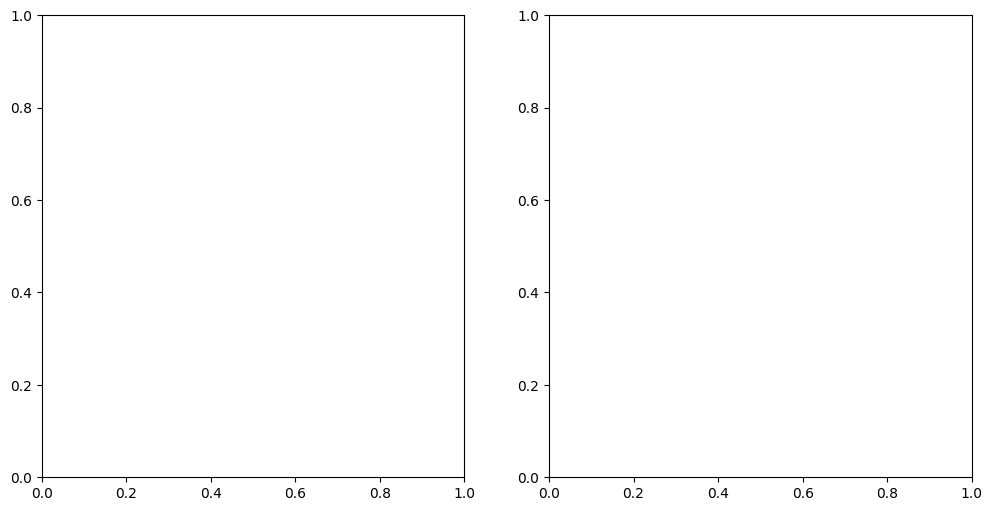

In [16]:
plot_metric_comparison(bpr_with_oracle, random_with_oracle, metric_name="mace", title="MACE over simulation rounds using BPR and Random Recs with Oracle Model", graph="line", plot_retrain_points=False)

A recomendação baseada em BPR apresenta muito menos ruído do que a recomendação aleatória. Porém, a oscilação do MACE apresenta um aspecto quase rítmico. 

Na figura acima, a curva laranja apresenta o MACE medido a cada iteração da simulação, enquanto que  a curva azul apresenta uma suavização com média móvel de tamanho 10. No gráfico abaixo (boxplot plotado utilizando os MACES de ambos os experimentos, lado a lado), podemos observar que, apesar de apresentarmos oscilação, o MACE é de fato menor no BPR, mostrando que o modelo está aprendendo preferëncias do usuário. 



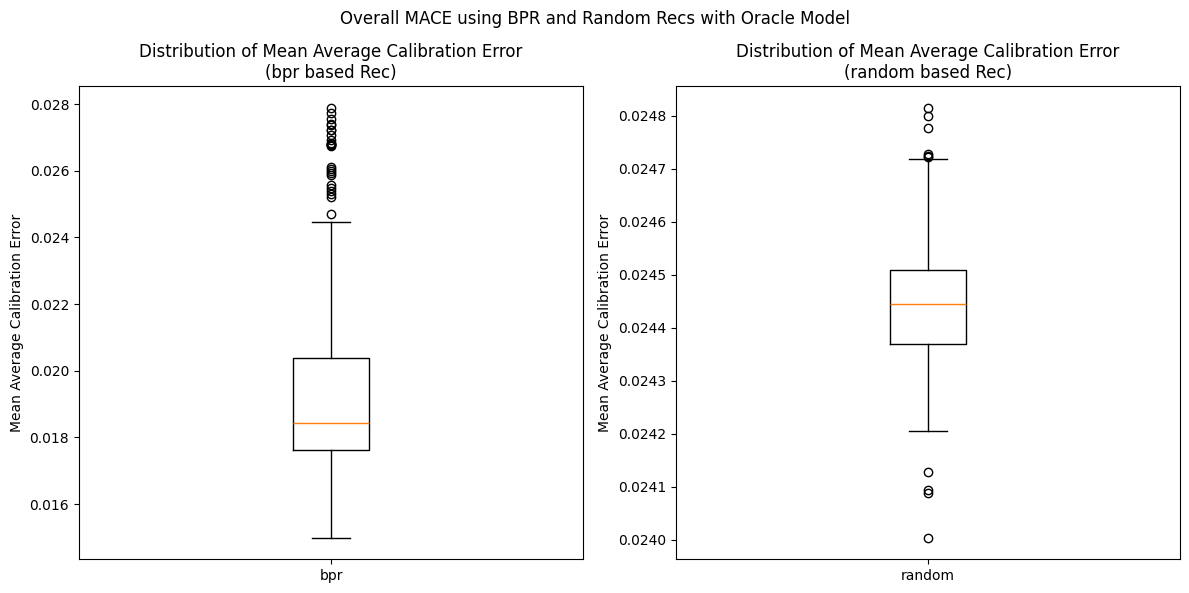

In [ ]:
plot_metric_comparison(bpr_with_oracle, random_with_oracle, metric_name="mace", title="Overall MACE using BPR and Random Recs with Oracle Model", graph="box")

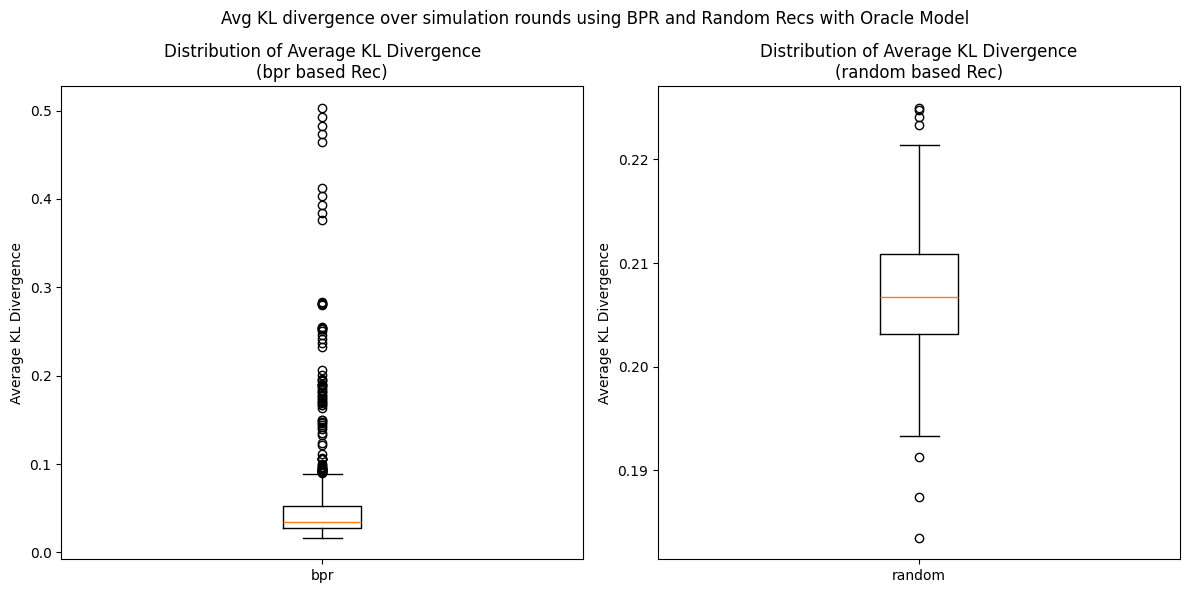

In [ ]:
plot_metric_comparison(bpr_with_oracle, random_with_oracle, metric_name="kl", title="Avg KL divergence over simulation rounds using BPR and Random Recs with Oracle Model", graph="box")

Essas conclusões são reforçadas pelas medições da divergência KL média, mais sensível a flutuações:

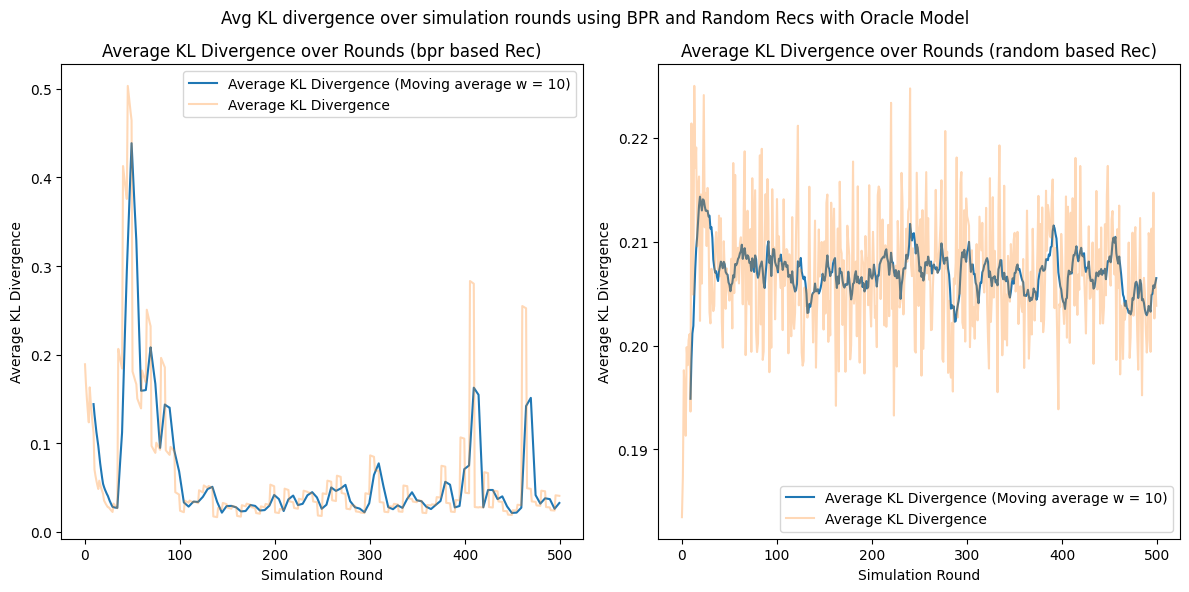

In [ ]:
plot_metric_comparison(bpr_with_oracle, random_with_oracle, metric_name="kl", title="Avg KL divergence over simulation rounds using BPR and Random Recs with Oracle Model", graph="line")

Ainda assim, é curioso o comportamento de flutuações. Plotei então, em vermelho, os rounds de simulação onde o modelo é retreinado, e podemos observar uma sobreposição perfeita entre  os pontos de retreino com os pontos de oscilação de MACE:

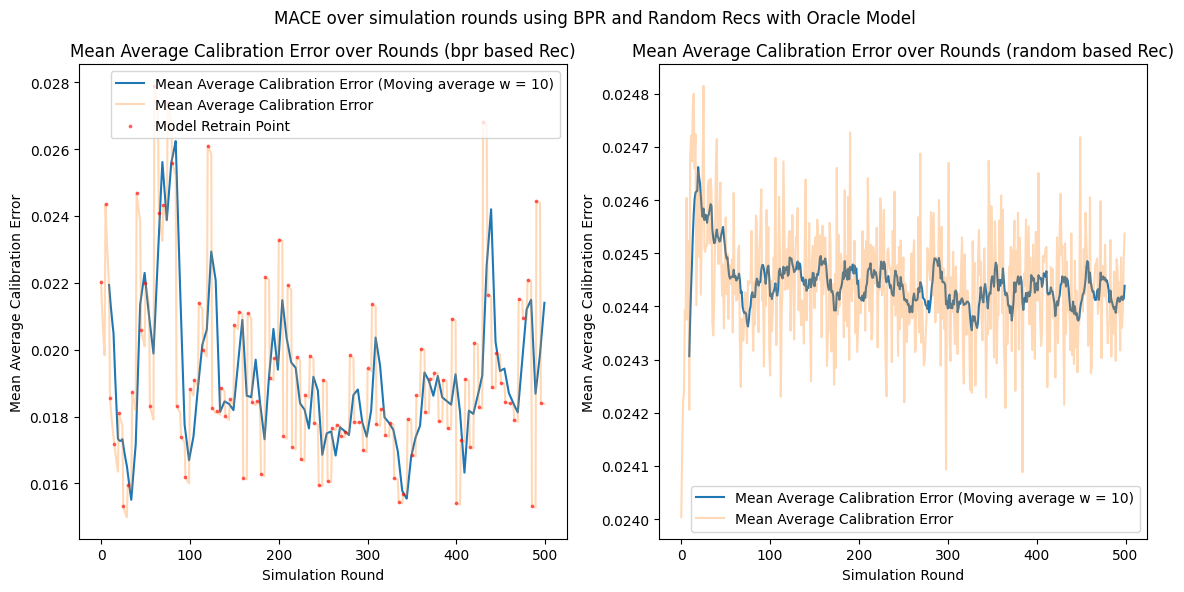

In [ ]:
plot_metric_comparison(bpr_with_oracle, random_with_oracle, metric_name="mace", title="MACE over simulation rounds using BPR and Random Recs with Oracle Model", graph="line", plot_retrain_points=True)

Para descartar a influência do modelo oráculo no ruído, geramos as figuras acima, porém, sem modelo oráculo. Abaixo, geramos a comparação entre BPR e Recomendação aleatória - ambos sem modelo oráculo - em termos de MACE por rodada, divergência KL média por rodada, e resumido ao longo da simulação, em um boxplot

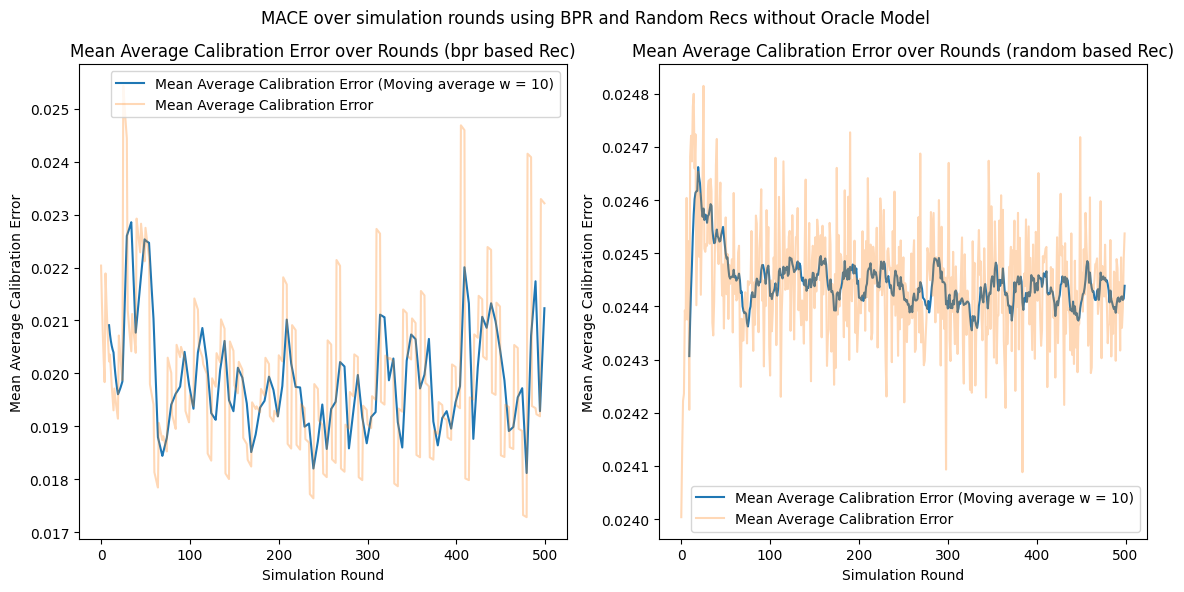

In [ ]:
plot_metric_comparison(bpr_no_oracle, random_no_oracle, metric_name="mace", title="MACE over simulation rounds using BPR and Random Recs without Oracle Model", graph="line")

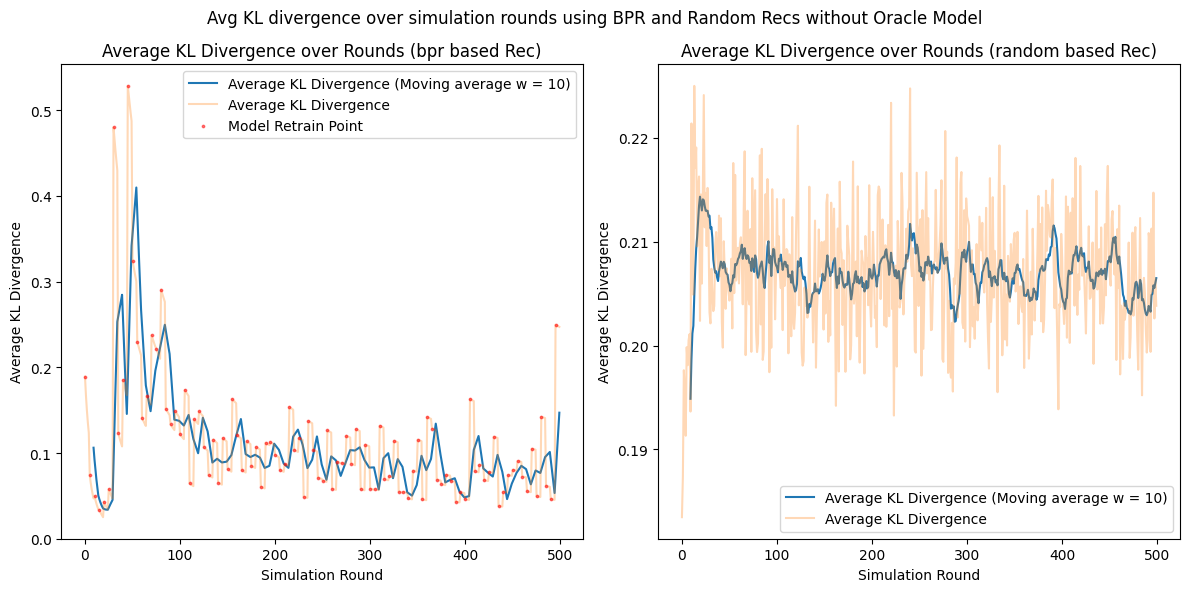

In [ ]:
plot_metric_comparison(bpr_no_oracle, random_no_oracle, metric_name="kl", title="Avg KL divergence over simulation rounds using BPR and Random Recs without Oracle Model", graph="line", plot_retrain_points=True)

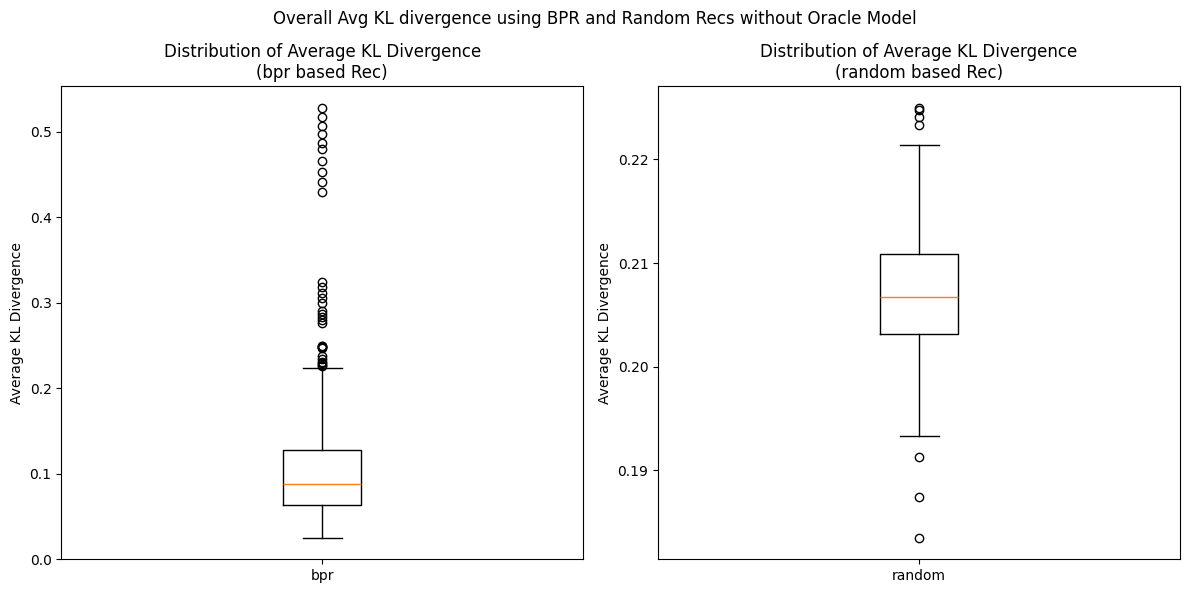

In [ ]:
plot_metric_comparison(bpr_no_oracle, random_no_oracle, metric_name="kl", title="Overall Avg KL divergence using BPR and Random Recs without Oracle Model", graph="box")

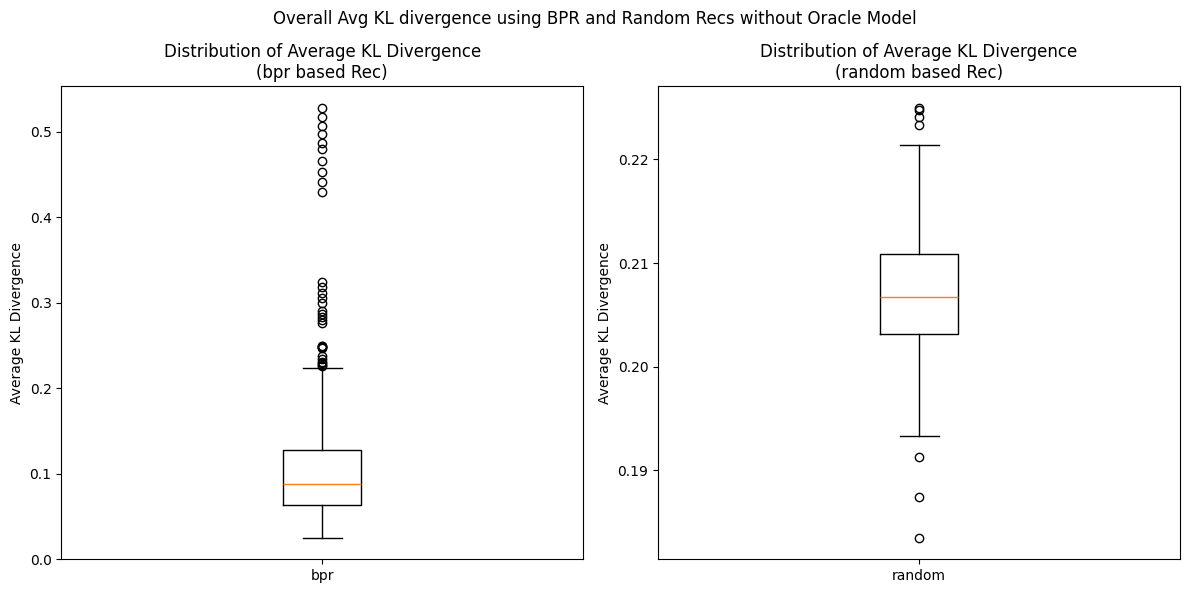

In [ ]:
plot_metric_comparison(bpr_no_oracle, random_no_oracle, metric_name="kl", title="Overall Avg KL divergence using BPR and Random Recs without Oracle Model", graph="box")

Com o exposto acima, podemos concluir que as oscilações observadas foram introduzidas durante retreinos. Abaixo iremos comparar lado a lado a simulação utilizando recomendação baseada em BPR com e sem oráculo

### Comparison between Oracle and no Oracle simulation

Vemos na figura abaixo um comportamento muito similar entre o modelo com oráculo (figura da esquerda) e sem oráculo (direita):

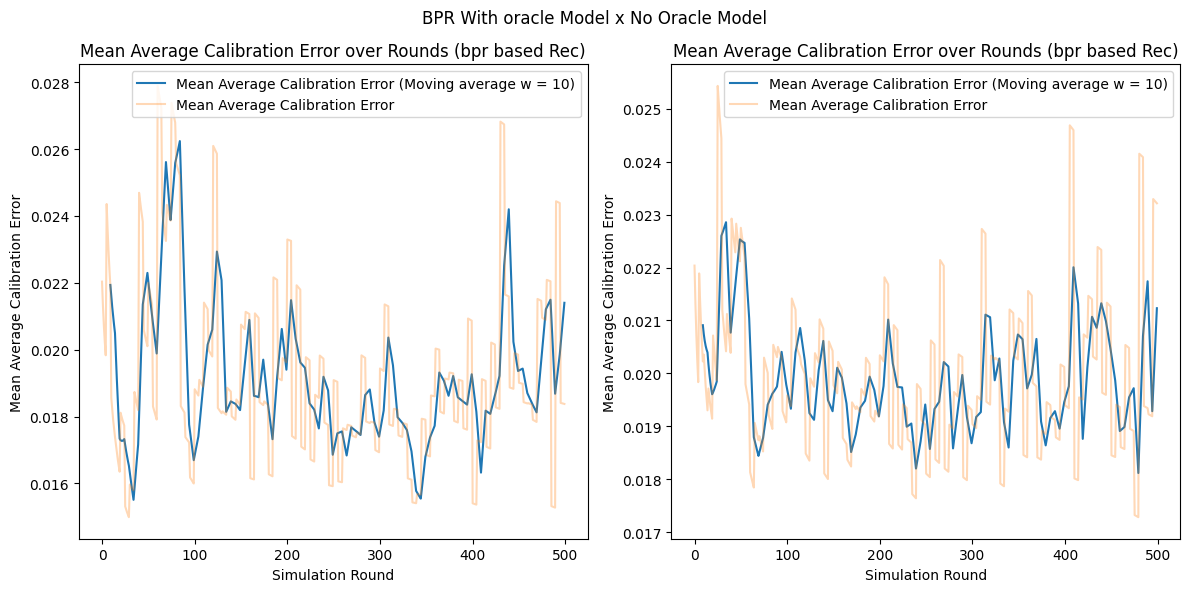

In [ ]:
plot_metric_comparison(bpr_with_oracle, bpr_no_oracle, metric_name="mace", title="BPR With oracle Model x No Oracle Model", graph="line")

O mesmo pode ser dito para a divergência KL

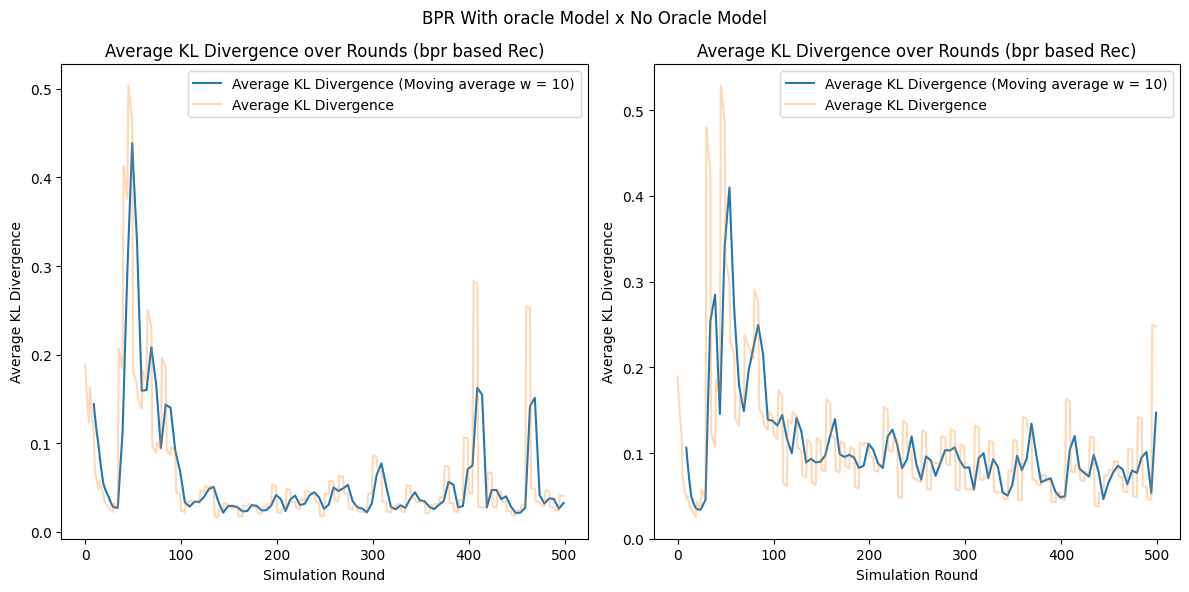

In [ ]:
plot_metric_comparison(bpr_with_oracle, bpr_no_oracle, metric_name="kl", title="BPR With oracle Model x No Oracle Model", graph="line")

Finalmente, comparamos o desempenho resumido ao longo da simulação. A recomendação com oráculo apresenta um desempenho ligeiramente melhor em termos de divergência KL, com mediana em torno de 0.02 enquanto que o modelo sem oráculo apresenta divergência kl média proxima a 0.1; As medidas de divergência KL são mais bem comprotadas para o cenário com modelo oráculo, com um boxplot mais enxuto, denotando uma distribuiçÃo concentrada de valores.

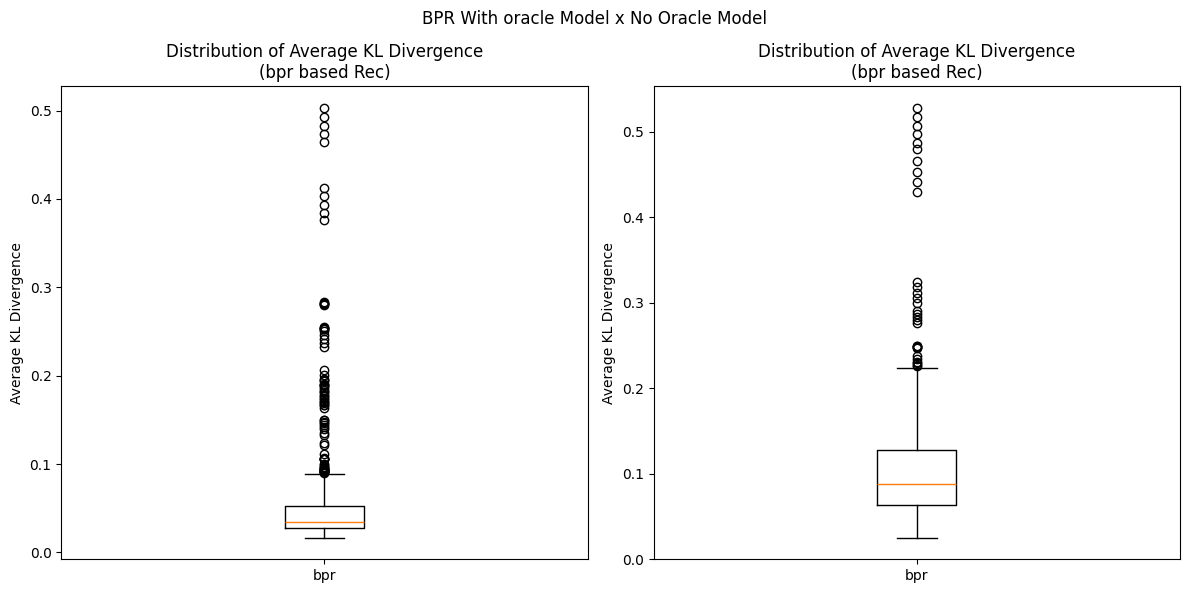

In [ ]:
plot_metric_comparison(bpr_with_oracle, bpr_no_oracle, metric_name="kl", title="BPR With oracle Model x No Oracle Model", graph="box")

Partindo para o MACE, uma medida menos sensível, os dois tipos de simulação geram resultados praticamente idênticos.

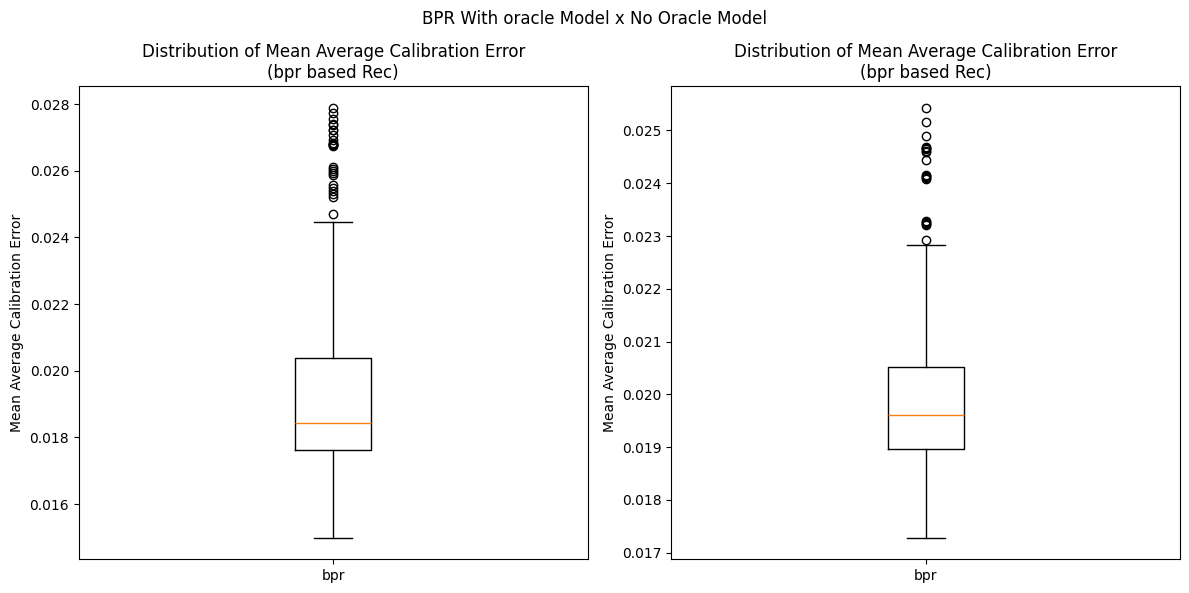

In [ ]:
plot_metric_comparison(bpr_with_oracle, bpr_no_oracle, metric_name="mace", title="BPR With oracle Model x No Oracle Model", graph="box")

Agora iremos mostrar a diferença nos intervalos de retreino e sua influência nas curvas.

## Trying out different retraining intervals

Variei o intervalo de retreino testando o retreino a cada 50, 100 e 250 iterações. Os resultados anteriores foram obtidos retreinando o modelo a cada 5 rodadas.

In [ ]:
L_50_exp = "bpr_with_oracle_experiment_L=50.yaml"
L_100_exp = "bpr_with_oracle_experiment_L=100.yaml"
L_250_exp = "bpr_with_oracle_experiment_L=250.yaml"

Analisando a curva de MACE e divergência KL (em comparação com o retreino a cada 5 iterações), já podemos observar que a figura se torna mais comportada, com os pontos de inflexão seguindo sendo relacionados a retreino.

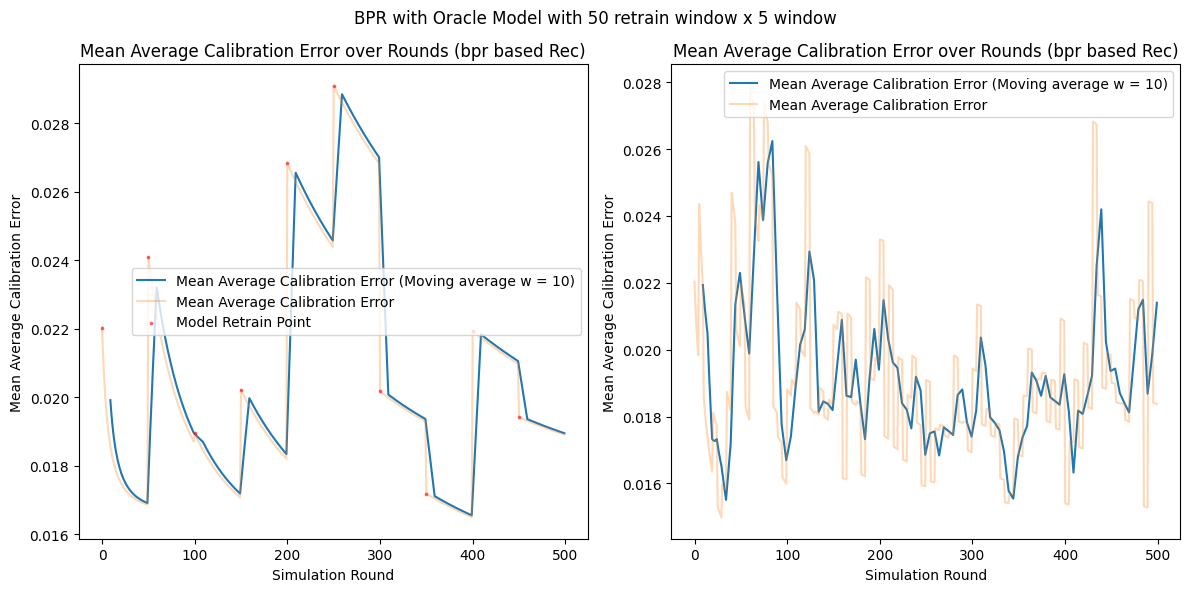

In [ ]:
plot_metric_comparison(L_50_exp, bpr_with_oracle, metric_name="mace", title="BPR with Oracle Model with 50 retrain window x 5 window", graph="line", plot_retrain_points=True)

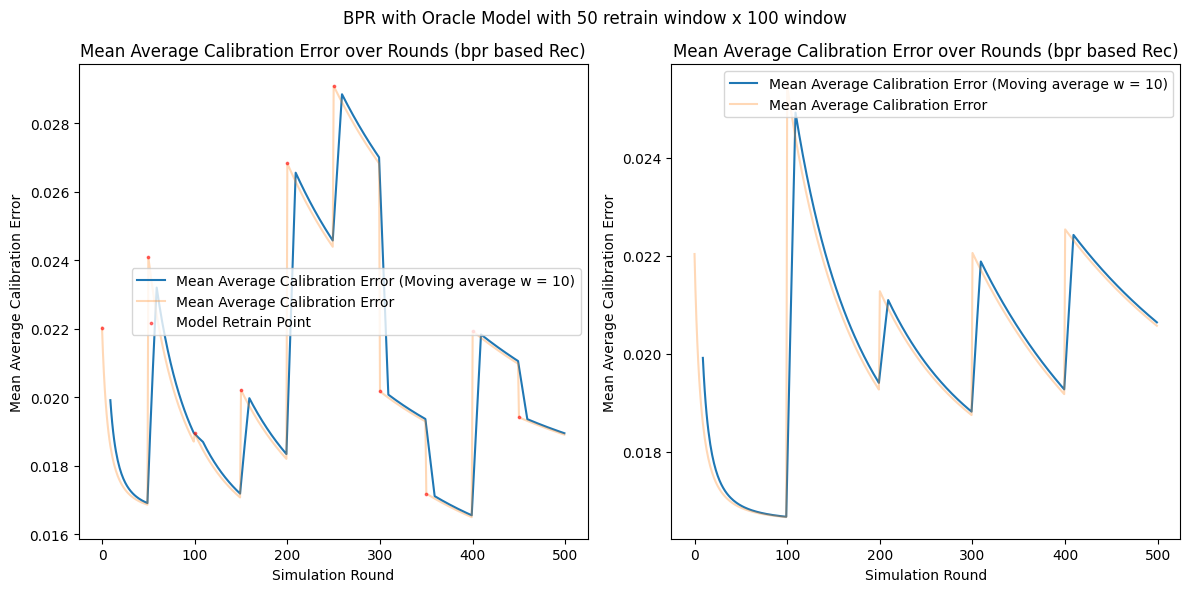

In [ ]:
plot_metric_comparison(L_50_exp, L_100_exp, metric_name="mace", title="BPR with Oracle Model with 50 retrain window x 100 window", graph="line", plot_retrain_points=True)

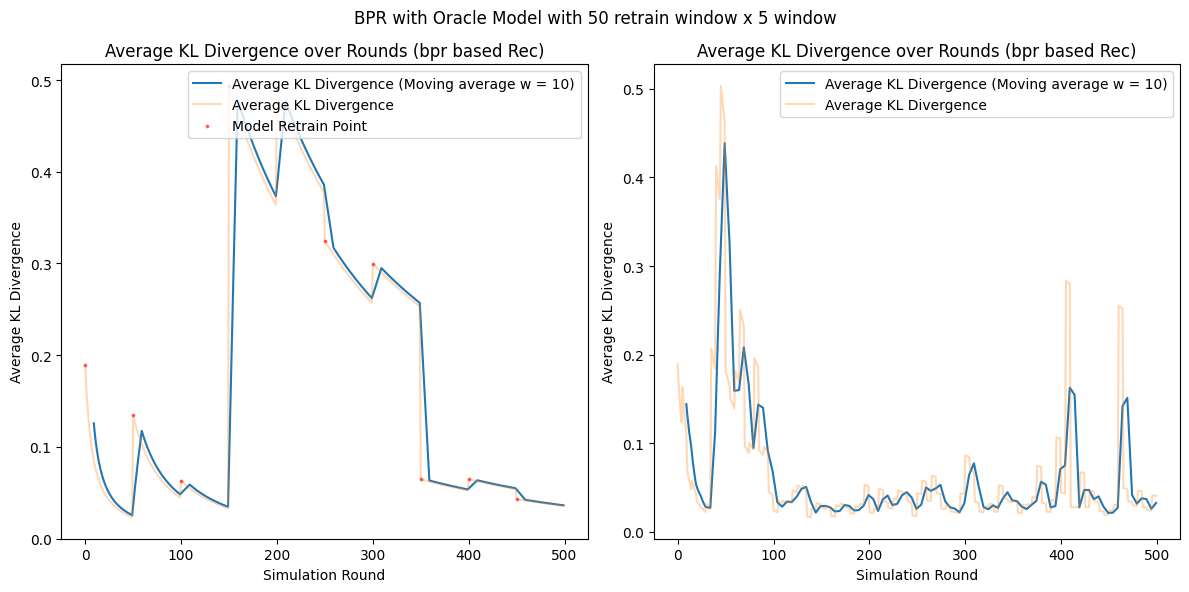

In [ ]:
plot_metric_comparison(L_50_exp, bpr_with_oracle, metric_name="kl", title="BPR with Oracle Model with 50 retrain window x 5 window", graph="line", plot_retrain_points=True)

Conforme diminuimos a frequencia do retreino, o padrão se mantém: ao longo da simulação, a divergência KL e MACE caem até o próximo retreino.

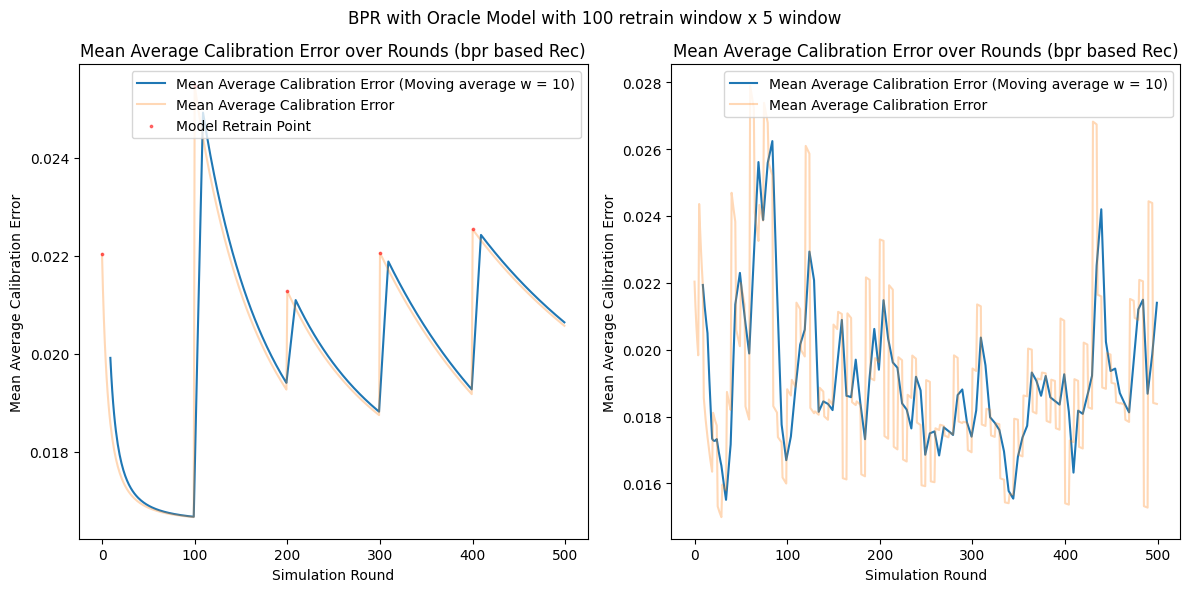

In [ ]:
plot_metric_comparison(L_100_exp, bpr_with_oracle, metric_name="mace", title="BPR with Oracle Model with 100 retrain window x 5 window", graph="line", plot_retrain_points=True)

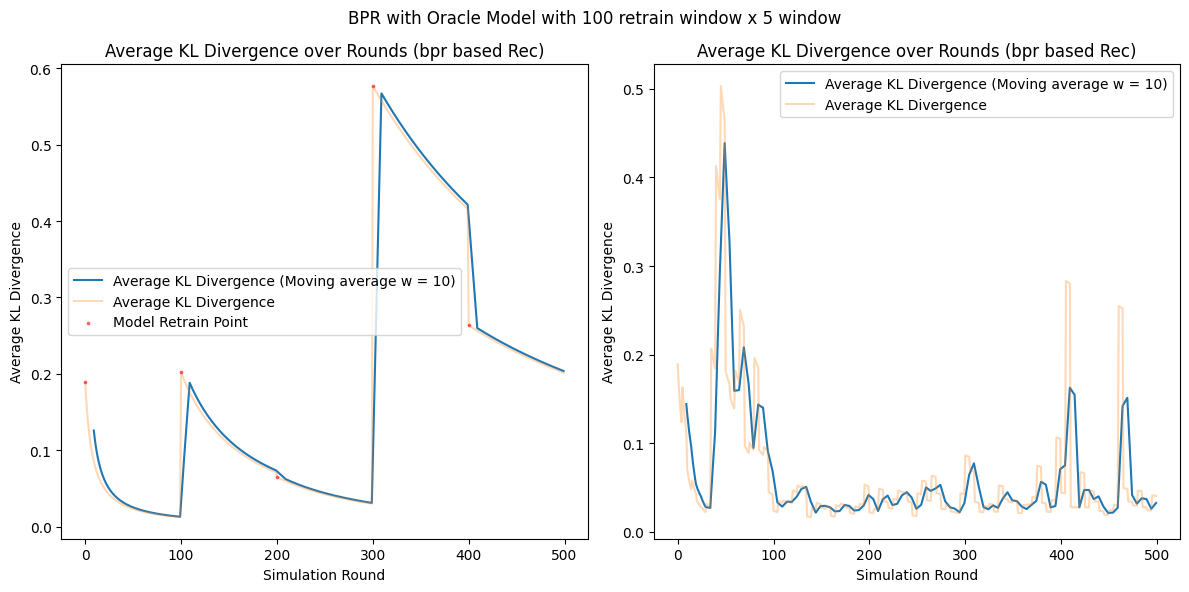

In [ ]:
plot_metric_comparison(L_100_exp, bpr_with_oracle, metric_name="KL", title="BPR with Oracle Model with 100 retrain window x 5 window", graph="line", plot_retrain_points=True)

Essa diferença se torna mais gritante ao realizar apenas 2 retreinos: 1 no início, e outro ao meio da simulação. Com isso, podemos concluir confiantemente que o retreino, como está estruturado atualmente, está gerando ruído na evolução do MACE e divergência KL ao longo da simulação.

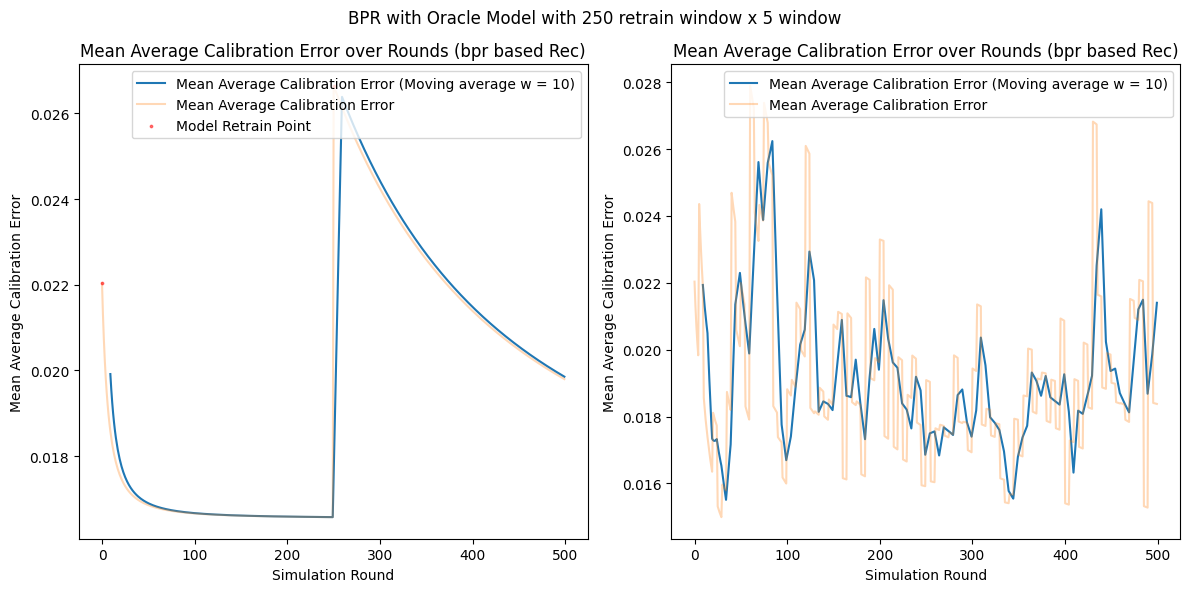

In [ ]:
plot_metric_comparison(L_250_exp, bpr_with_oracle, metric_name="mace", title="BPR with Oracle Model with 250 retrain window x 5 window", graph="line", plot_retrain_points=True)

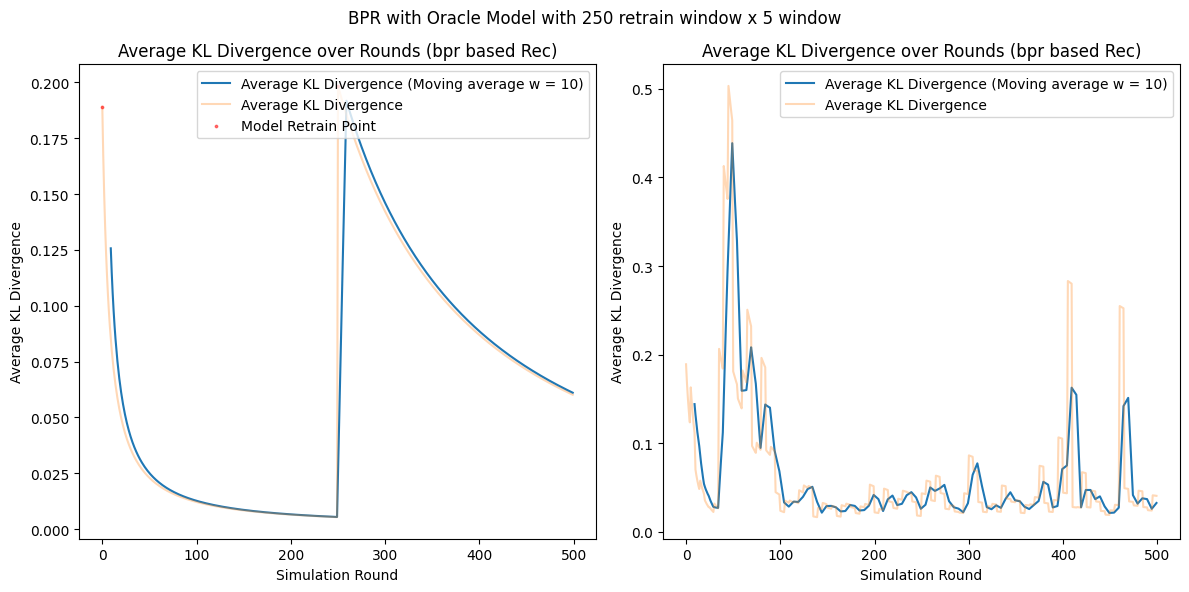

In [ ]:
plot_metric_comparison(L_250_exp, bpr_with_oracle, metric_name="kl", title="BPR with Oracle Model with 250 retrain window x 5 window", graph="line", plot_retrain_points=True)

Finalmente, observo se há uma diferença de comportamento, com menos janela de retreinos, entre o modelo com oráculo ou sem oráculo. O comportamento das duas curvas é muito similar: uma queda em termos de MACE e KL Div após cada retreino, subindo veritiginosamente a cada retreino. Uma leve diferença se nota ao analisar a divergência KL em detrimento do MACE, com o modelo sem oráculo apresentando um comportamento com uma divergência ligeiramente menor.

In [ ]:
L_250_exp_no_oracle = "bpr_no_oracle_experiment_L=250.yaml"

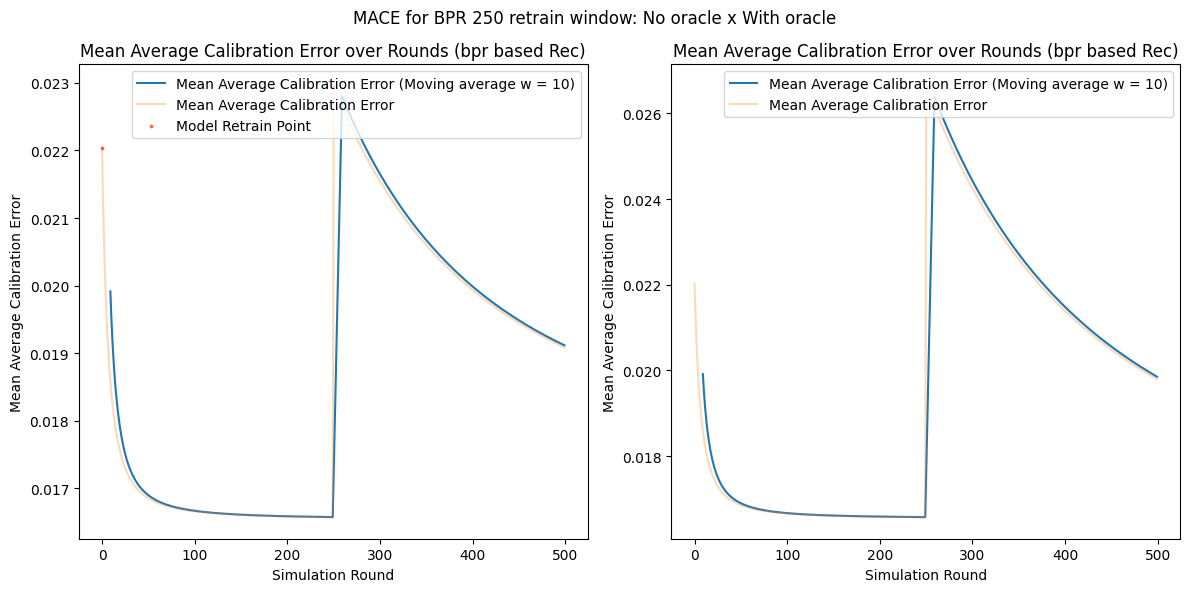

In [ ]:
plot_metric_comparison(L_250_exp_no_oracle, L_250_exp, metric_name="MACE", title="MACE for BPR 250 retrain window: No oracle x With oracle", graph="line", plot_retrain_points=True)   

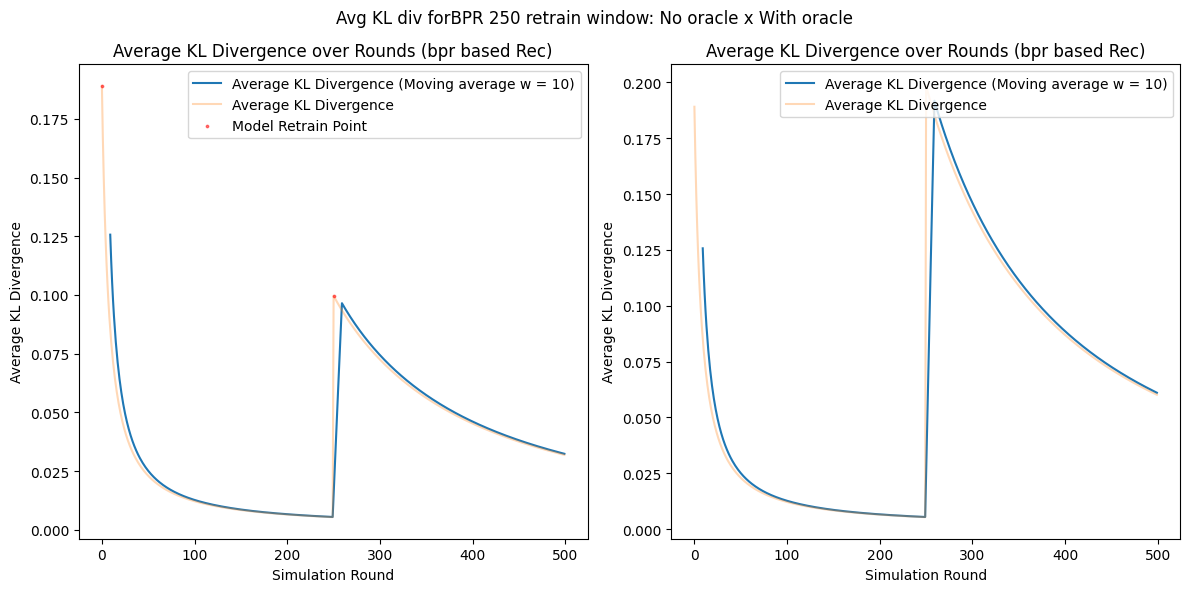

In [ ]:
plot_metric_comparison(L_250_exp_no_oracle, L_250_exp, metric_name="KL", title="Avg KL div forBPR 250 retrain window: No oracle x With oracle", graph="line", plot_retrain_points=True)   

## Próximos passos


Dado o que foi descoberto, irei alterar a metodologia de retreino. 



Ao invés de acumular cliques simulados e realizar re-treinos neste conjunto cada vez maior (ou seja, retreinar o modelo no conjunto $D$ inteiro), irei fatiar o conjunto de cliques acumulados, retendo apenas uma porção dos cliques mais recentes. Em outras palavras, podemos treinar o modelo no conjunto $D_L \cup D_{L-1} \dots \cup D_{L-7}$, por exemplo. Lembrando que $L$ é uma rodada onde o modelo é retreinado.


Isso garante algumas propriedades interessantes e positivas para a simulação, por exemplo:

1. quantidade constante de dados a cada retreino
2. Simulação com melhor fidelidade um  ambiente de produção de recomendação
3. Possibilidade de realizar a simulação para mais usuários (hoje, fixamos em 1000 usuários amostrados aleatoriamente como exposto anteriormente).


Estando de acordo com essa metodologia da simulação, pretendo começar a aplicar calibração para as recomendações e comparar os resultados.



## Dúvidas em aberto


Dois pontos que estão em aberto para mim e gostaria de dicutir:

1. Como detalhado no início, comparo a recomendação gerada na k-ésima iteração ($R_k$) com o histórico inicial $H_0$. Isso faz sentido? Ou é melhor comparar os itens clicados na k-esima iteração com $H_0$? Refletindo melhor na análise, tendo a pensar que é melhor comparar os itens clicados durante a iteração com os itens clicados no início.
2. Qual um conjunto razoável para treinar o modelo durante a simulação? No exemplo acima adotei uma janela de treino de $k=7$ iterações passadas. Faz sentido?


## Utilizando a estratégia de mover o retreino

In [ ]:
rolling_exp = "experiments/bpr_no_oracle_experiment_with_rolling.yaml"
rolling_with_oracle_exp = "experiments/bpr_with_oracle_experiment_with_rolling.yaml"
big_one = "experiments/bpr_with_oracle_experiment_big_one.yaml"
big_one_classic = "experiments/bpr_classic_big_one.yaml"

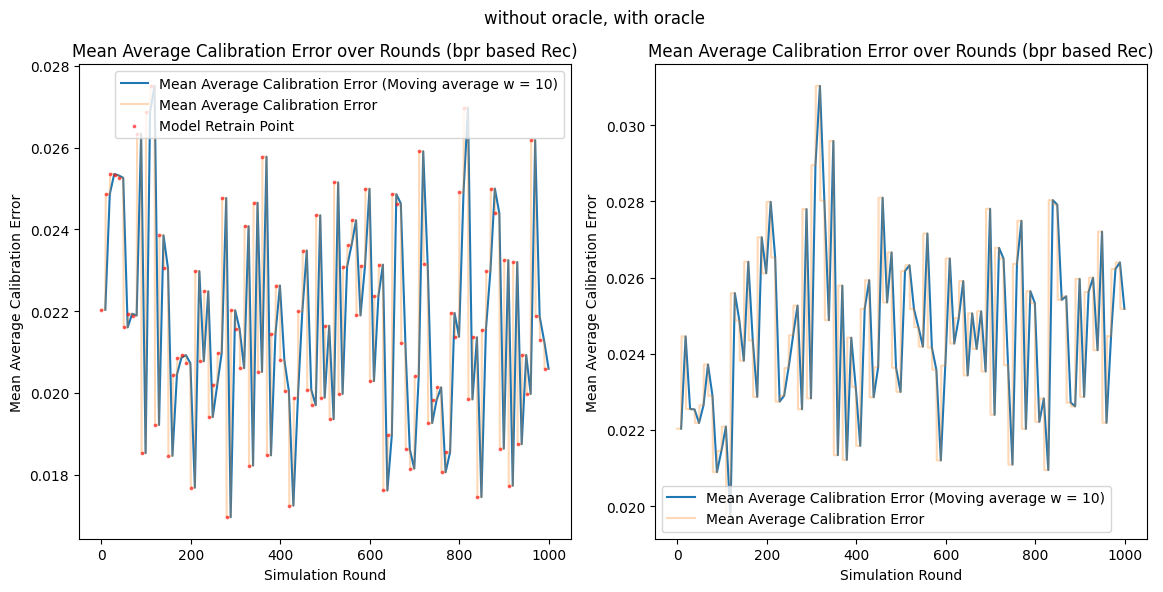

In [ ]:
plot_metric_comparison(rolling_exp, rolling_with_oracle_exp, metric_name="mace", title="without oracle, with oracle", graph="line", plot_retrain_points=True)

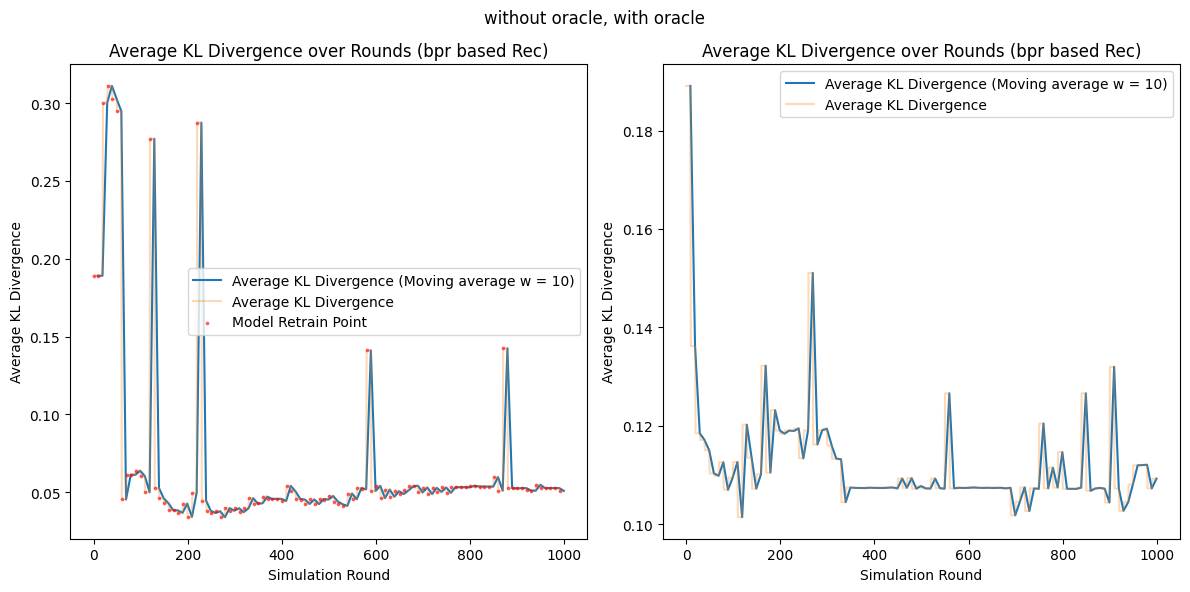

In [ ]:
plot_metric_comparison(rolling_exp, rolling_with_oracle_exp, metric_name="kl", title="without oracle, with oracle", graph="line", plot_retrain_points=True)

## Using 40.0000 iterations

In [ ]:
from dynamicTasteDistortion.ioUtils import read_experiment, read_metrics

In [ ]:

big_one_classic_exp = read_experiment(big_one_classic)
mace, kl = read_metrics(big_one_classic_exp)

TypeError: expected str, bytes or os.PathLike object, not dict

In [33]:
exp = read_experiment(big_one)
mace, kl = read_metrics(exp)

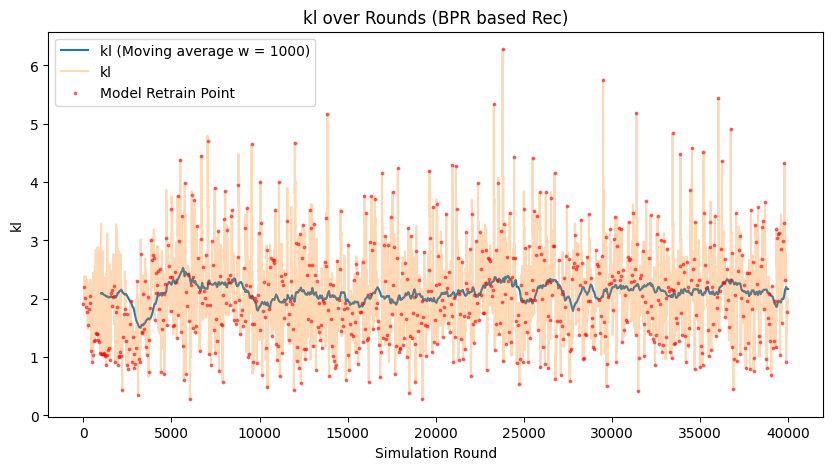

In [36]:
# Versão removendo itens do histórico antes de recomendar.
plot_metrics_smoothed(ax=None, metric=kl, model_name="BPR", metric_name="kl", step=exp["num_rounds_per_eval"], window_size=1000)

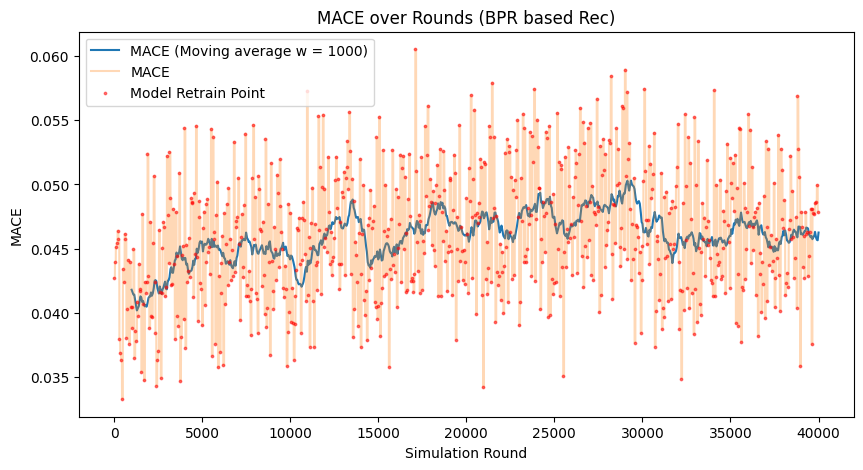

In [45]:
plot_metrics_smoothed(ax=None, metric=mace, model_name="BPR", metric_name="MACE", step=exp["num_rounds_per_eval"], window_size=1000)